# Exploring gen data

### AIM
* To perform a detailed analysis of the dataset gen_data.csv. 
* To explore the statistical measures and plot these findings on a graph.
* To evaluate how these variables are related to each other.

### METHODS
* A set of python tools were imported into the datset including- matplotlib, panads, numpy and seaborn.
* Dataset gen_data.csv was converted into a pandas dataframe.
* Data was arranged into different columns- A, B, C, D, E, outcome and treatment.

Importing the required packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

Inputing the data frame

In [2]:
df=pd.read_csv("gen_data_1000.csv")

Quick command to check what kind of data is there in the columns

In [3]:
df.head()

,A,B,C,D,E,outcome,treatment
0,-2.863469,-0.075805,-0.284494,1,3.866439,5.564749,1
1,0.699450,1.251749,-1.237323,1,0.804800,5.543024,1
2,0.565525,-0.328845,0.626817,1,-0.031784,0.160138,0
3,-1.774796,-1.766976,-1.253474,1,1.654755,5.032822,1
4,-0.678966,-0.294244,0.509223,1,-0.226398,4.686563,1


Describing mean, median, standard deviation, minimum and maximum values for all the columns

In [4]:
#50% quartile is the median
df.describe()

,A,B,C,D,E,outcome,treatment
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.224231,0.173350,-0.684213,0.734000,0.894695,3.596546,0.664000
std,1.000983,0.983229,0.988332,0.442085,0.988375,2.496567,0.472575
min,-3.731729,-2.524961,-3.962974,0.000000,-1.986842,-1.051414,0.000000
25%,-0.879716,-0.499713,-1.340325,0.000000,0.211632,0.481646,0.000000
50%,-0.226633,0.162491,-0.746945,1.000000,0.910057,5.020893,1.000000
75%,0.502808,0.850100,-0.012035,1.000000,1.550718,5.476952,1.000000
max,3.121376,2.963297,2.080929,1.000000,3.866439,6.765928,1.000000


Bar chart for column D

<function matplotlib.pyplot.show(close=None, block=None)>

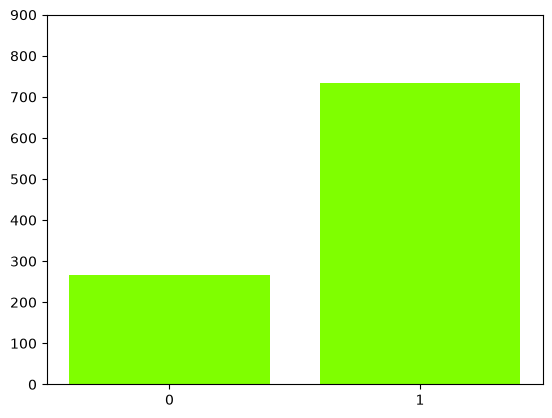

In [5]:
#D only has yes or no values
s=df["D"].value_counts()
binsx=s.index.values
binsy=np.arange(0,1000,100)
plt.bar(s.index,s.values,color="Chartreuse")
plt.xticks(binsx)
plt.yticks(binsy)
plt.show

Histogram for column A, B, C and E

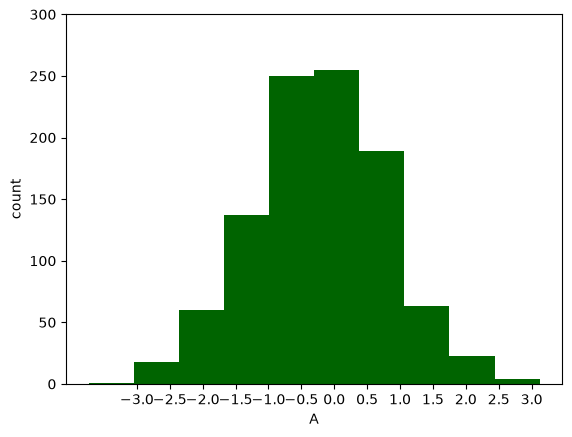

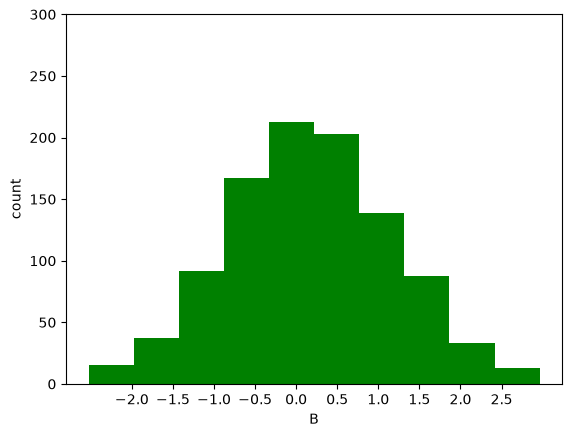

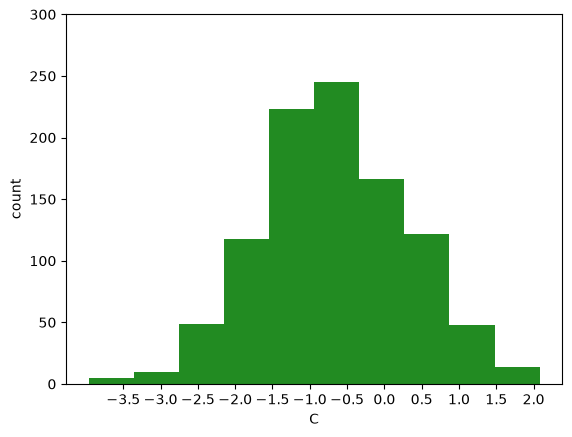

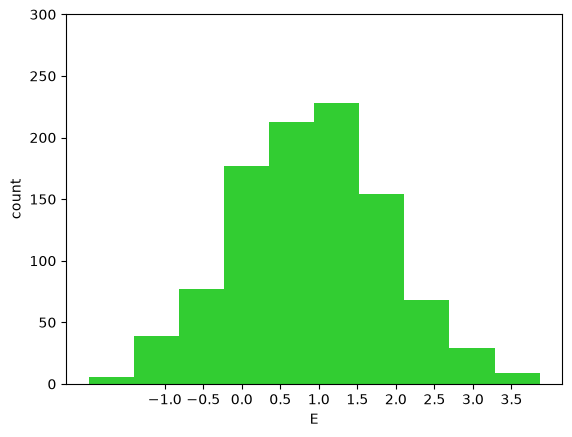

In [6]:
dict_binsx={"A":np.arange(-3,3.5,0.5),"B":np.arange(-2,3,0.5),"C":np.arange(-3.5,2.5,0.5),"E":np.arange(-1,4,0.5)}
dict_binsy={"A":np.arange(0,350,50),"B":np.arange(0,350,50),"C":np.arange(0,350,50),"E":np.arange(0,350,50)}
dict_color={"A":"DarkGreen", "B":"Green", "C":"ForestGreen", "E":"LimeGreen"}
for col in ["A","B","C","E"]:
    plt.hist(df[col],color=dict_color[col])
    plt.xticks(dict_binsx[col])
    plt.yticks(dict_binsy[col])
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

Histogram for outcomes

<function matplotlib.pyplot.show(close=None, block=None)>

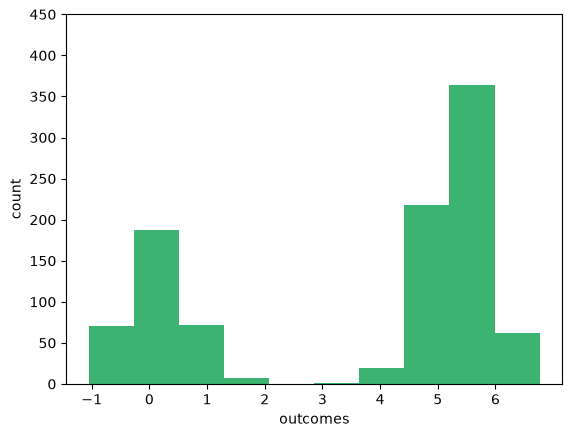

In [7]:
binsx=np.arange(-1,7,1)
binsy=np.arange(0,500,50)
plt.hist(df["outcome"],color="MediumSeaGreen")
plt.xticks(binsx)
plt.yticks(binsy)
plt.xlabel("outcomes")
plt.ylabel("count")
plt.show

Bar Chart for Treatment

<function matplotlib.pyplot.show(close=None, block=None)>

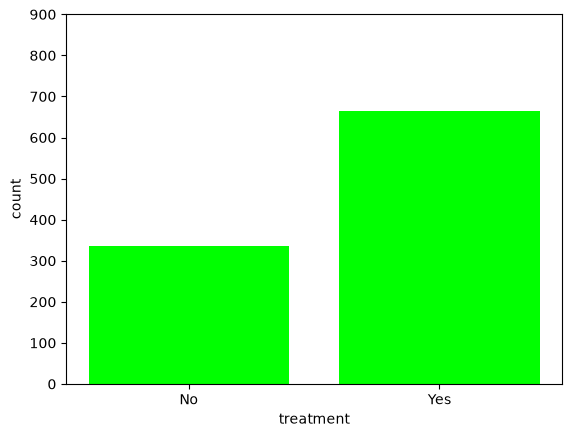

In [8]:
#treatment only has yes or no values
t=df["treatment"].value_counts()
binsx=t.index
binsy=np.arange(0,1000,100)

dict_label={0:"No", 1:"Yes"}
labels=[]
for col in binsx:
    a=dict_label[col]
    labels.append(a)

plt.bar(t.index,t.values,color="Lime")
plt.xticks(binsx,labels=labels)
plt.yticks(binsy)
plt.xlabel("treatment")
plt.ylabel("count")
plt.show

Outcomes of the people treated/not treated

<function matplotlib.pyplot.show(close=None, block=None)>

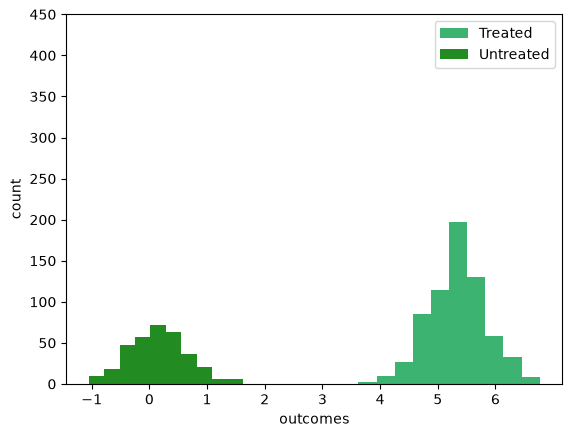

In [9]:
mask=df["treatment"] == 1
dftreat=df.loc[mask]#everyone who was treated
dfuntreat=df.loc[~mask] #32 (number of untreated)
binsx=np.arange(-1,7,1)
binsy=np.arange(0,500,50)
plt.hist(dftreat["outcome"],color="MediumSeaGreen", label="Treated")
plt.hist(dfuntreat["outcome"],color="ForestGreen", label="Untreated")
plt.legend()
plt.xticks(binsx)
plt.yticks(binsy)
plt.xlabel("outcomes")
plt.ylabel("count")
plt.show

Pearson Correlation Heatmap for all columns

                  A         B         C         D         E   outcome  \
A          1.000000 -0.051073  0.029074  0.038220 -0.001184  0.279704   
B         -0.051073  1.000000 -0.028411  0.001226 -0.002177 -0.027529   
C          0.029074 -0.028411  1.000000 -0.021399 -0.035616 -0.009383   
D          0.038220  0.001226 -0.021399  1.000000  0.019605  0.233043   
E         -0.001184 -0.002177 -0.035616  0.019605  1.000000  0.230444   
outcome    0.279704 -0.027529 -0.009383  0.233043  0.230444  1.000000   
treatment  0.156679 -0.026677 -0.008304  0.237766  0.080541  0.979775   

           treatment  
A           0.156679  
B          -0.026677  
C          -0.008304  
D           0.237766  
E           0.080541  
outcome     0.979775  
treatment   1.000000  


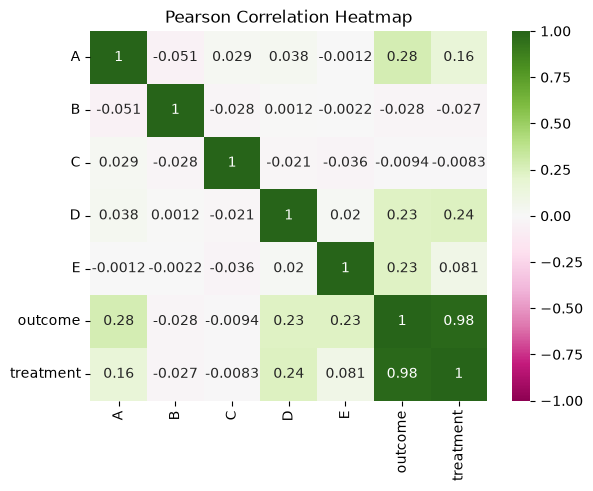

In [10]:
pearson_corr = df.corr(method='pearson')
print(pearson_corr)

sns.heatmap(pearson_corr, annot=True, cmap='PiYG', vmin=-1, vmax=1)
plt.title("Pearson Correlation Heatmap")
plt.show()

Calculating correlation between treatment and outcome (it is pearson by default)

In [11]:
x = df["treatment"]
y = df["outcome"]
correlation = x.corr(y)
correlation 

np.float64(0.97977500905156)

Code to avoid same gruping again and again (so if there is A vs B already there will be no repeat of B vs A)

In [12]:
column_names = df.columns

for i, col1 in enumerate(column_names):
    for j, col2 in enumerate(column_names[i+1:]):
        print(i, j, col1, col2)

0 0 A B
0 1 A C
0 2 A D
0 3 A E
0 4 A outcome
0 5 A treatment
1 0 B C
1 1 B D
1 2 B E
1 3 B outcome
1 4 B treatment
2 0 C D
2 1 C E
2 2 C outcome
2 3 C treatment
3 0 D E
3 1 D outcome
3 2 D treatment
4 0 E outcome
4 1 E treatment
5 0 outcome treatment


For loop to run all the different columns against each other

0 0 treatment treatment
Correlation between A and B: -0.05107322841859027


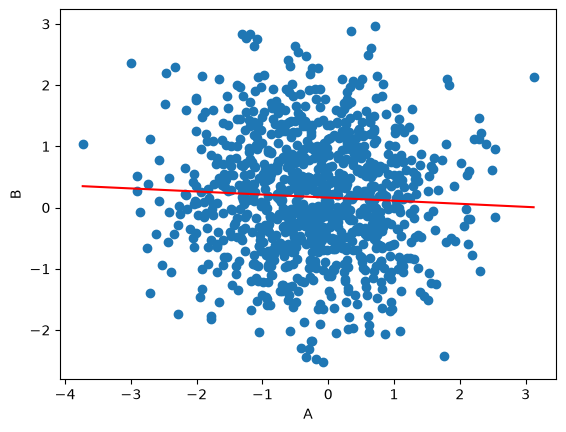

0 1 treatment treatment
Correlation between A and C: 0.029074351888349847


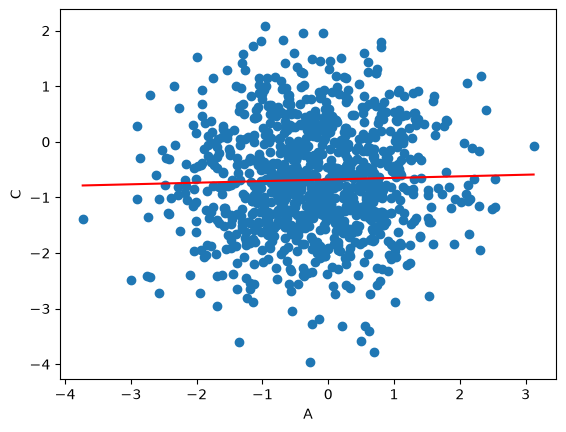

0 2 treatment treatment
Correlation between A and D: 0.03822038488382119


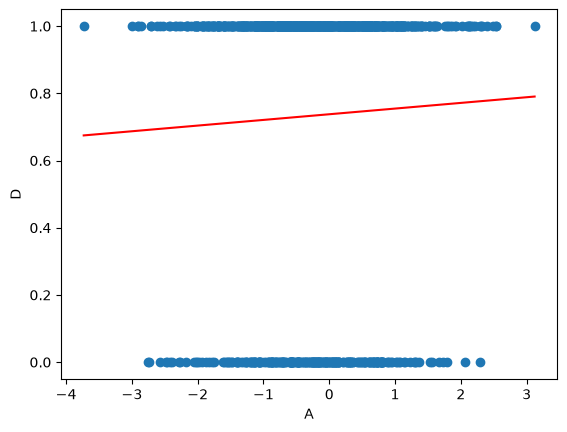

0 3 treatment treatment
Correlation between A and E: -0.0011839011096060547


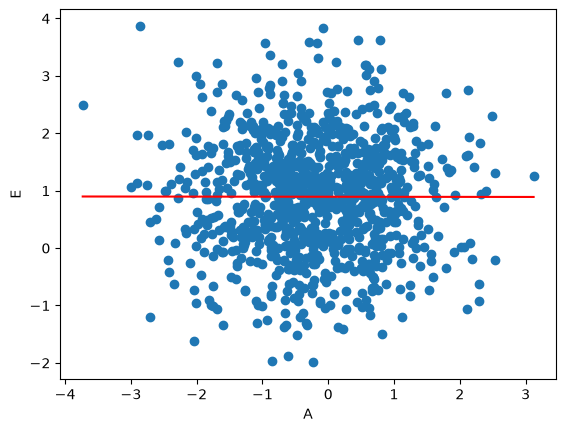

0 4 treatment treatment
Correlation between A and outcome: 0.27970385006331094


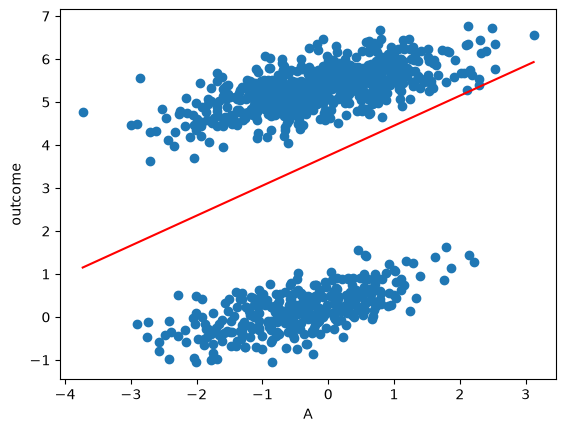

0 5 treatment treatment
Correlation between A and treatment: 0.15667896114311813


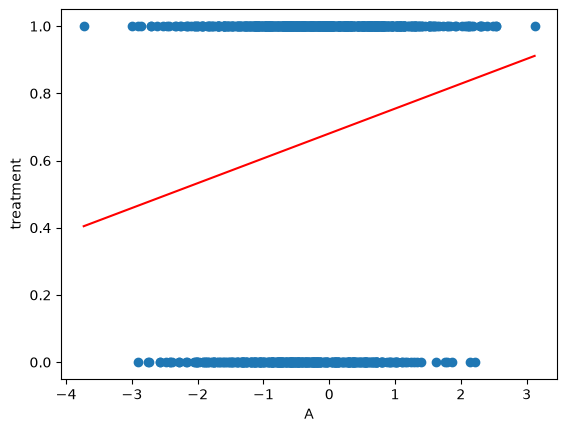

1 0 treatment treatment
Correlation between B and C: -0.028411374489258203


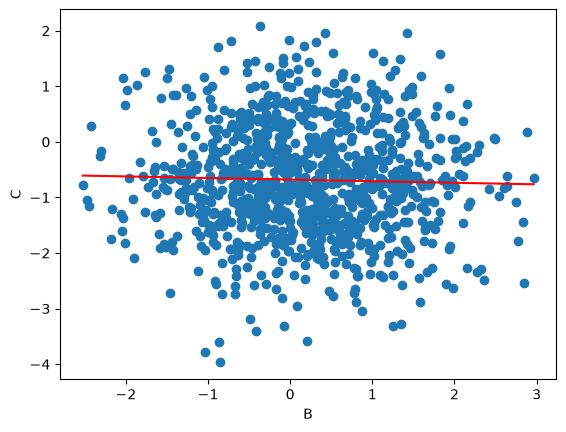

1 1 treatment treatment
Correlation between B and D: 0.0012263722528631062


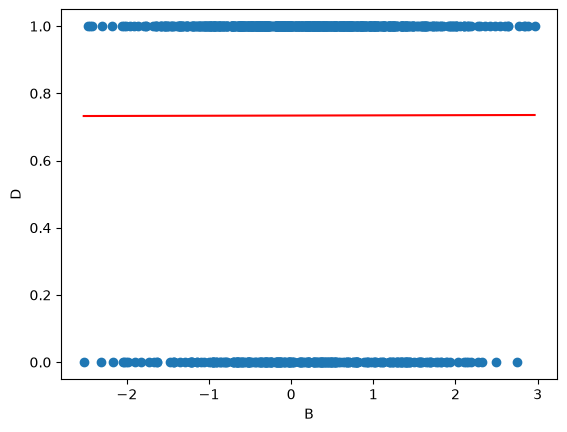

1 2 treatment treatment
Correlation between B and E: -0.002176561401220119


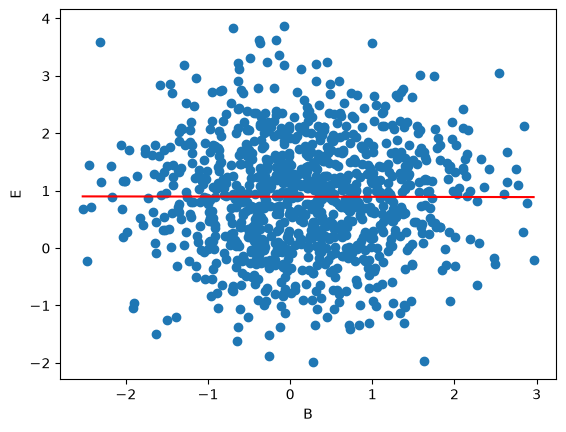

1 3 treatment treatment
Correlation between B and outcome: -0.027529201048997635


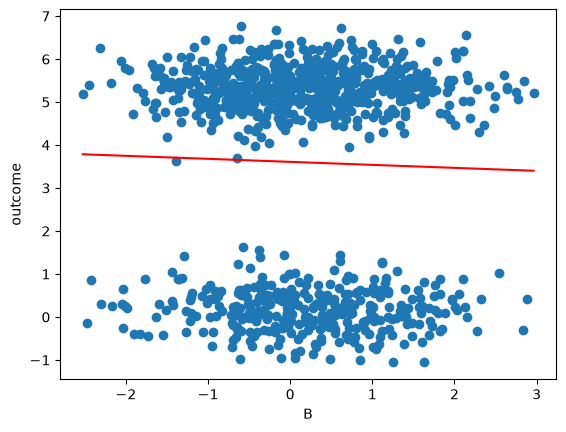

1 4 treatment treatment
Correlation between B and treatment: -0.026676556295684013


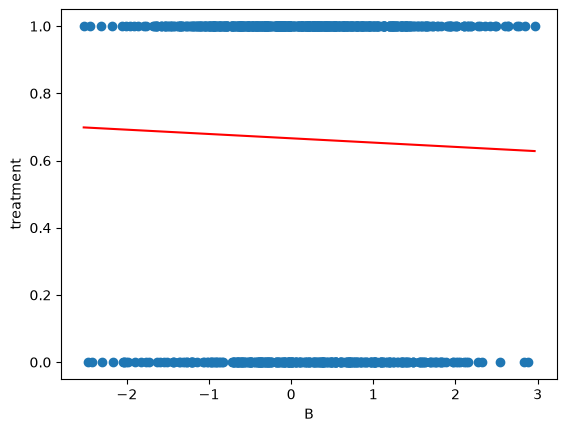

2 0 treatment treatment
Correlation between C and D: -0.021399193981887367


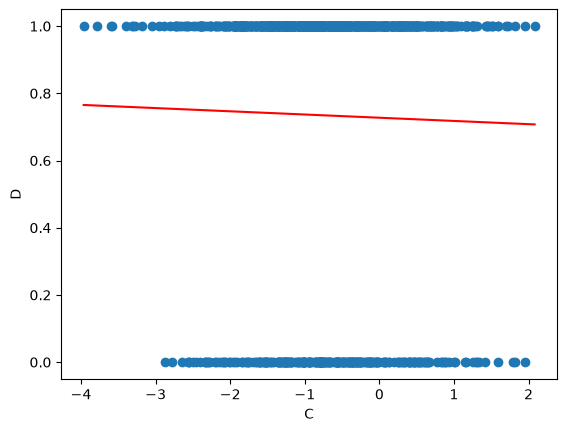

2 1 treatment treatment
Correlation between C and E: -0.035615703858584195


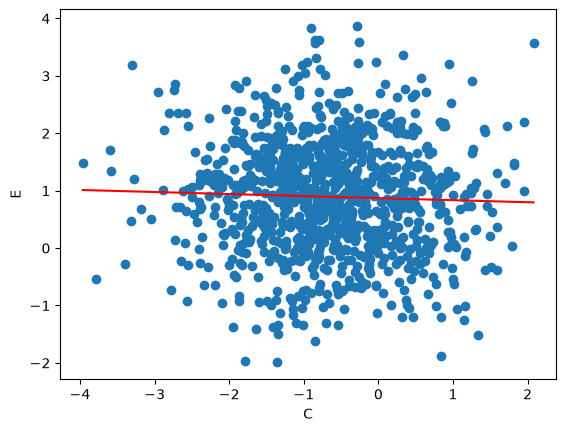

2 2 treatment treatment
Correlation between C and outcome: -0.00938336053114545


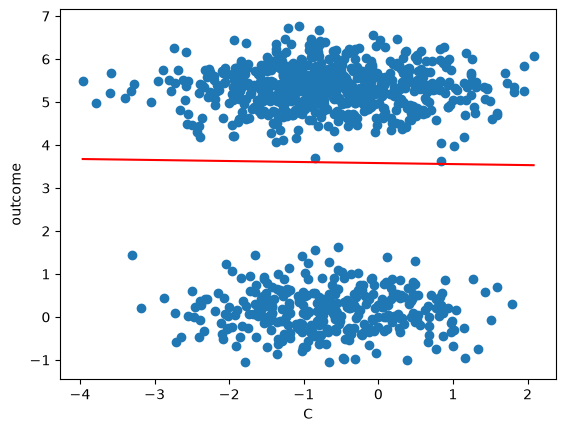

2 3 treatment treatment
Correlation between C and treatment: -0.008303779138837201


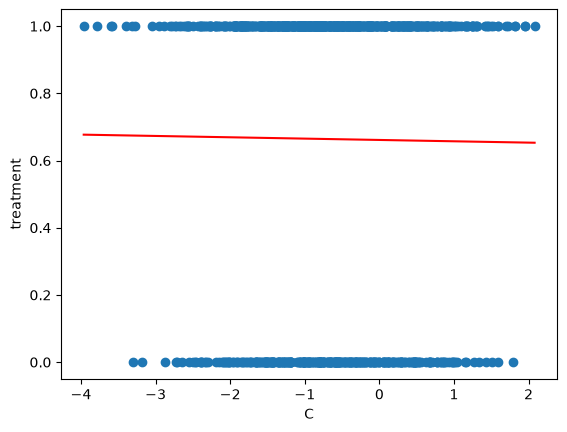

3 0 treatment treatment
Correlation between D and E: 0.019604852681324548


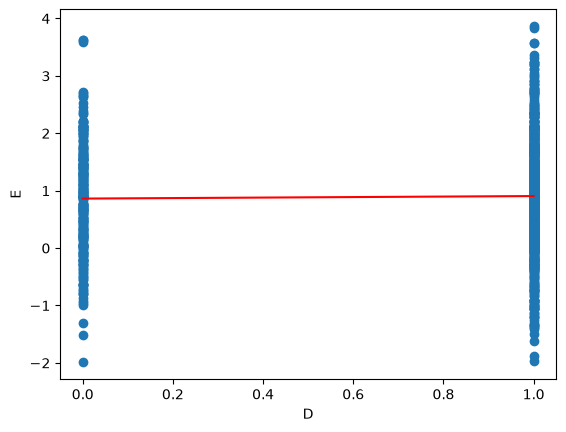

3 1 treatment treatment
Correlation between D and outcome: 0.23304326695858218


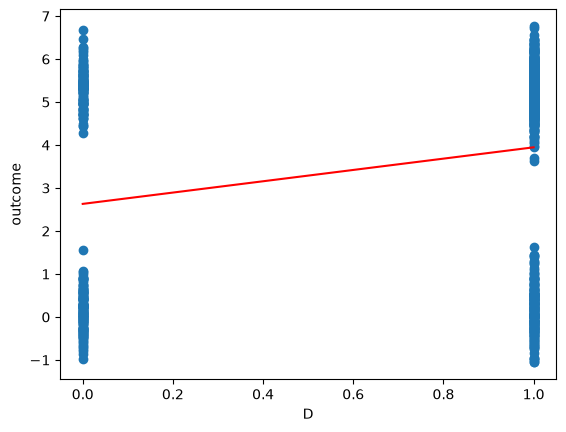

3 2 treatment treatment
Correlation between D and treatment: 0.23776572073794602


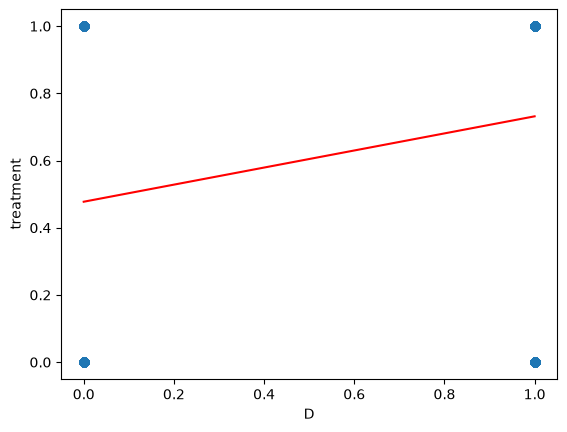

4 0 treatment treatment
Correlation between E and outcome: 0.23044436851592162


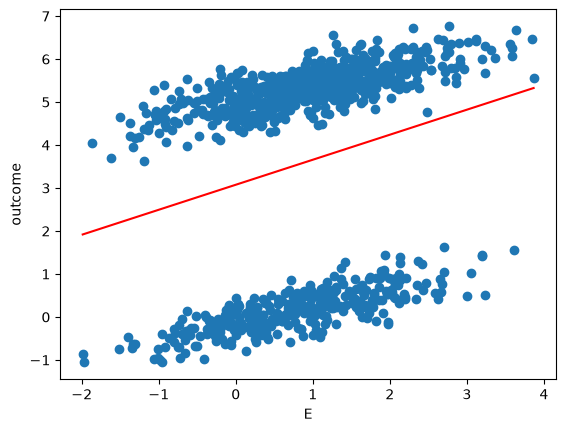

4 1 treatment treatment
Correlation between E and treatment: 0.08054060198007536


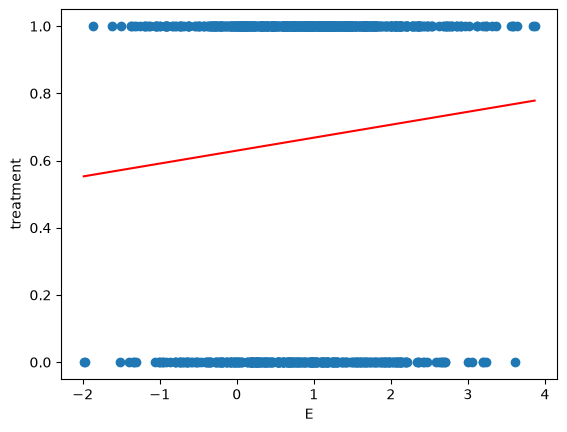

5 0 treatment treatment
Correlation between outcome and treatment: 0.9797750090515599


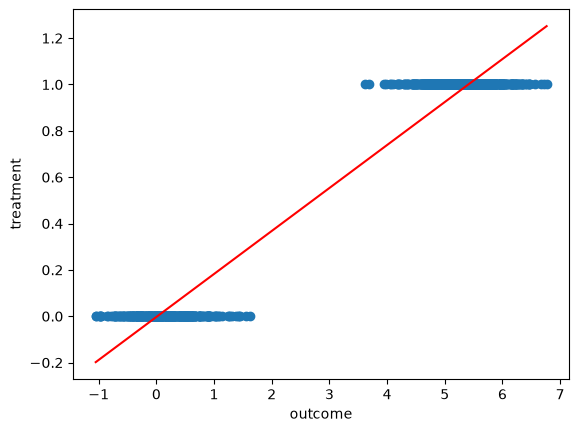

In [13]:
column_names = df.columns

for i, x in enumerate(column_names):
    for j, y in enumerate(column_names[i+1:]):
        print(i, j, col1, col2)
        if x != y:
            correlation = df[x].corr(df[y])
            print(f"Correlation between {x} and {y}: {correlation}")
            # plotting the data
            plt.scatter(df[x], df[y])

            plt.plot(np.unique(df[x]), np.poly1d(np.polyfit(df[x], df[y], 1))
                    (np.unique(df[x])), color='red')
            plt.xlabel(x)
            plt.ylabel(y)
            plt.show()

Histogram for particularly the relationship between D and treatment (both are binary values)

<function matplotlib.pyplot.show(close=None, block=None)>

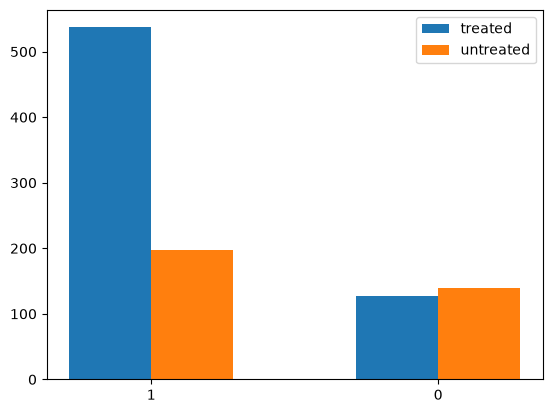

In [14]:
df_data=df[["D","treatment"]]

mask_1=(df_data["treatment"] == 1) & (df_data["D"] == 1)
df_d1_treat=df_data.loc[mask_1] #everyone who was treated and D=1

mask_2=(df_data["treatment"] == 1) & (df_data["D"] == 0)
df_d0_treat=df_data.loc[mask_2] #everyone who was treated and D=0

mask_3=(df_data["treatment"] == 0) & (df_data["D"] == 0)
df_d0_untreat=df_data.loc[mask_3] #everyone who was not treated and D=0

mask_4=(df_data["treatment"] == 0) & (df_data["D"] == 1)
df_d1_untreat=df_data.loc[mask_4] #everyone who was not treated and D=1

dataset_treat=[len(df_d1_treat), len(df_d0_treat)]
dataset_untreat=[len(df_d1_untreat), len(df_d0_untreat)]

plt.grouped_bar([dataset_treat, dataset_untreat], tick_labels=[1,0], labels=["treated","untreated"])
plt.legend()
plt.show

#if need to count the values of different bars use- df_d1_treat[["D","treatment"]].value_counts()

Making a histogram for A, B, C, E relationship with treatment

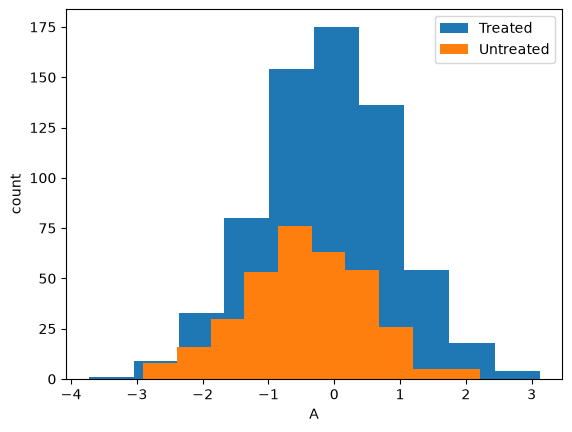

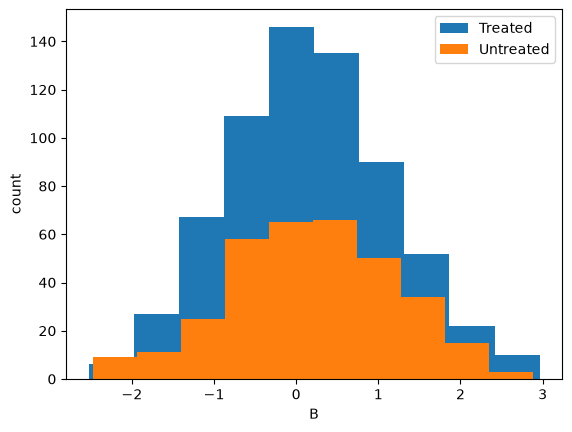

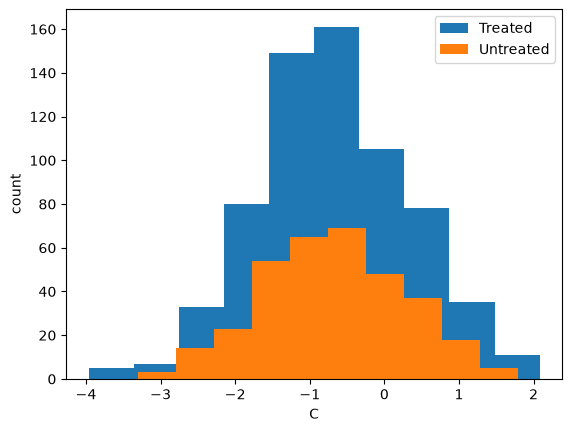

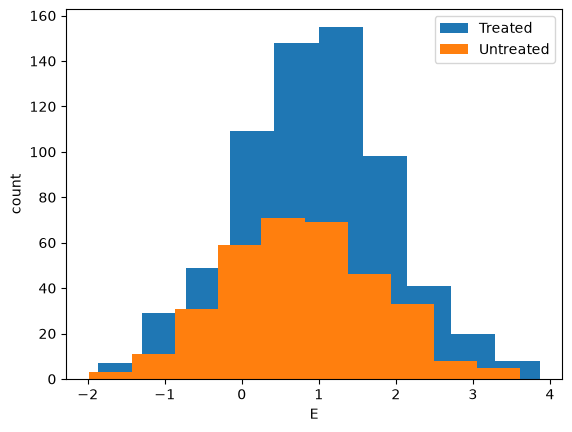

In [15]:
df_data_2=df[["A","B","C","E","treatment"]]

mask_5=(df_data_2["treatment"] == 1)
df_A_treat=df_data_2.loc[mask_5,"A"] #everyone who was treated in column A
df_A_untreat=df_data_2.loc[~mask_5,"A"] #everyone who was not treated in column A
plt.hist(df_A_treat, label="Treated")
plt.hist(df_A_untreat, label="Untreated")
plt.legend()
plt.xlabel("A")
plt.ylabel("count")
plt.show()

mask_6=(df_data_2["treatment"] == 1)
df_B_treat=df_data_2.loc[mask_6,"B"] #everyone who was treated in column B
df_B_untreat=df_data_2.loc[~mask_6,"B"] #everyone who was not treated in column B
plt.hist(df_B_treat, label="Treated")
plt.hist(df_B_untreat, label="Untreated")
plt.legend()
plt.xlabel("B")
plt.ylabel("count") 
plt.show()

mask_7=(df_data_2["treatment"] == 1)
df_C_treat=df_data_2.loc[mask_7,"C"] #everyone who was treated in column C
df_C_untreat=df_data_2.loc[~mask_7,"C"] #everyone who was not treated in column C
plt.hist(df_C_treat, label="Treated")
plt.hist(df_C_untreat, label="Untreated")
plt.legend()
plt.xlabel("C")
plt.ylabel("count")
plt.show()

mask_8=(df_data_2["treatment"] == 1)
df_E_treat=df_data_2.loc[mask_8,"E"] #everyone who was treated in column E
df_E_untreat=df_data_2.loc[~mask_8,"E"] #everyone who was not treated in column E
plt.hist(df_E_treat, label="Treated")
plt.hist(df_E_untreat, label="Untreated")
plt.legend()
plt.xlabel("E")
plt.ylabel("count")
plt.show()

Same histogram with a for loop + making one of the lines dashed to clearly see

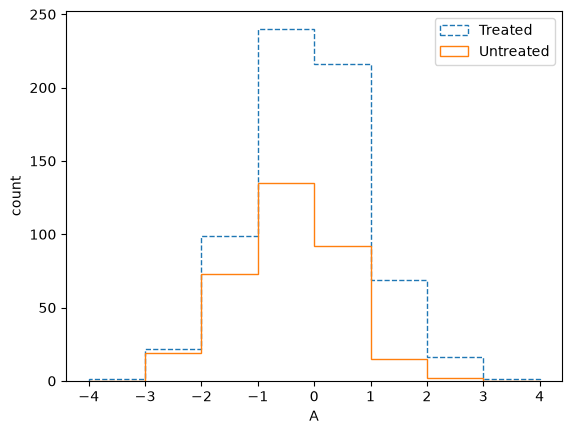

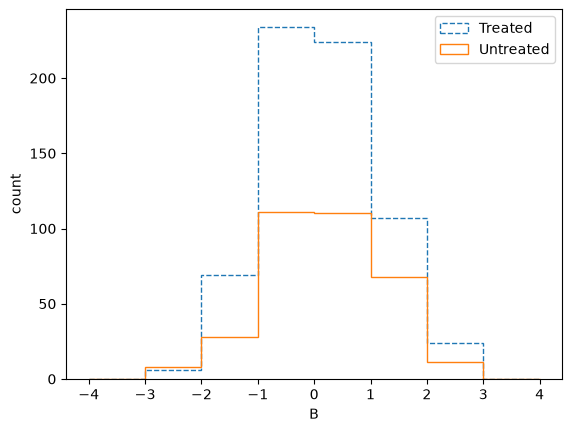

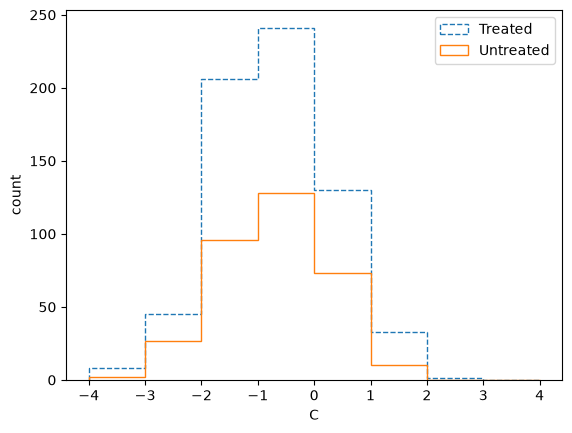

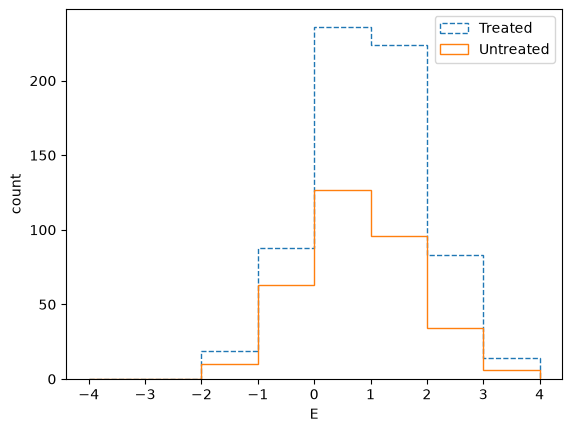

In [16]:
z=["A","B","C","E"]

for x in z:
    mask_9=(df_data_2["treatment"] == 1)
    df_x_treat=df_data_2.loc[mask_5,x] #everyone who was treated in column A
    df_x_untreat=df_data_2.loc[~mask_5,x] #everyone who was not treated in column A
    binsx=np.arange(-4,5,1)
    plt.hist(df_x_treat, label="Treated",bins=binsx,histtype="step", linestyle="dashed")
    plt.hist(df_x_untreat, label="Untreated",bins=binsx,histtype="step")
    plt.legend()
    plt.xticks(binsx)
    plt.xlabel(x)
    plt.ylabel("count")
    plt.show()

### RESULTS

Upon analysis using pearson correlation:
* Relationship of all variables with each other was 1
* A strong correlation was seen between outcome and treatment with a coefficient of 0.98, indicating that everytime treatment was given there was a positive outcome.
* Some more weak correlations were seen between: A and treatment (0.16), A and outcome (0.28), D and treatment (0.24), D and outcome (0.23)

Further histogram was made to assess the relationship between D and treatment as both were binary values. It showed that whenever D was 1, there was a much higher likelihood of treatment being provided. 

A similar histogram was made to assess the relationship between other variables and treatment likelihood but there were no significant findings seen except a weak relationship between A and treatment. 